# Telco-Churn-Guard

Hinweis zur Nutzung:
Dieses Jupyter Notebook dient der explorativen Datenanalyse (EDA) und der interaktiven Dokumentation. Die hier generierten Diagramme werden temporär
angezeigt.

Für den produktiven Einsatz und die automatisierte Speicherung der Visualisierungen (als .png) nutzen Sie bitte die main.py.
Dieser automatisierte Workflow stellt die Datenkonsistenz sicher und archiviert die Ergebnisse im Ordner /plots.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Daten mit pandas laden
df = pd.read_csv('telco_data.csv')

#Churn rate aus Daten exportieren
churn_rate = df[df['Churn'] == 'Yes']
#Festlegung der Größe
plt.figure(figsize=(10,6))
#weißes Gitter zum besseren Überblick hinzugefügt
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

## 1. Die Churn-Kurve: Identifikation von kritischen Phasen

Text(0, 0.5, 'Anzahl der Kündigungen')

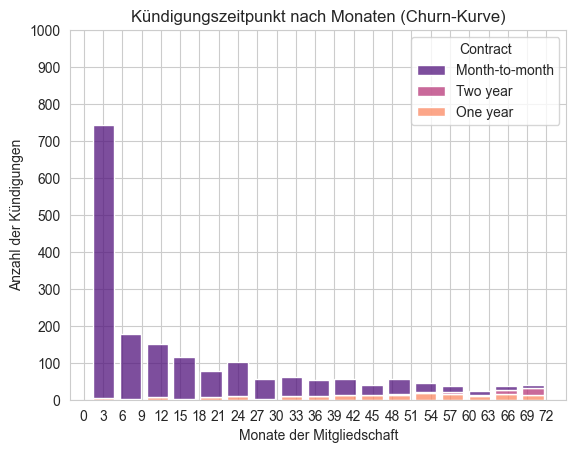

In [11]:
sns.histplot(data = churn_rate, x = 'tenure', hue = 'Contract', shrink=.8, multiple= "stack", palette = 'magma')
#Als Datenmenge nutze ich alle Kunden, die gekündigt haben. Die X-Achse beschreibt den Zeitpunkt und die Y-Achse die Anzahl. Mit hue und stack teile ich diese so auf, dass visuell eifach zu erkennen ist welcher Vertrag betroffen ist

plt.xticks(np.arange(0, 73, 3))   #-> X-Achse zählt von 0-72 in 3er Schritten
plt.yticks(np.arange(0, 1001, 100))     #-> Y-Achso zählt von 0-1000 in 100er Schritten

#Beschriftung
plt.title('Kündigungszeitpunkt nach Monaten (Churn-Kurve)')
plt.xlabel('Monate der Mitgliedschaft')
plt.ylabel('Anzahl der Kündigungen')

Analyse: Ein massiver Anstieg der Kündigungen (Churn) erfolgt bereits im ersten Monat (tenure = 1). Dies deutet auf Probleme beim Onboarding oder fehlerhafte Erwartungsmanagement hin. Kunden, die das erste Jahr "überleben", zeigen eine signifikant höhere Loyalität.

## 2. Gruppierung des monatlichen Verlust zum jeweiligen Vertragstypen

Text(0, 0.5, 'Potentieller monatlicher Umsatzverlust')

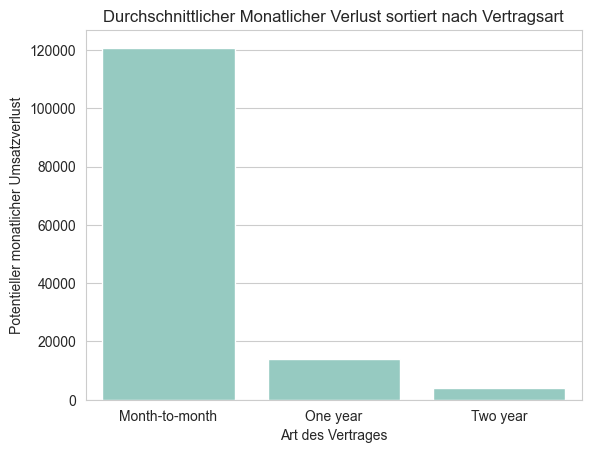

In [4]:
#Gruppierung der Monthly Charges zum jeweiligen Contract
total_lost_revenue = churn_rate.groupby('Contract')['MonthlyCharges'].sum().reset_index()
#-> mit .reset_index() wandle ich den index in ein DataFrame um, da nur dieses Format akzeptiert wird

#visualisierung
sns.barplot(data = total_lost_revenue, x = 'Contract', y = 'MonthlyCharges')

#Beschriftung
plt.title('Durchschnittlicher Monatlicher Verlust sortiert nach Vertragsart')
plt.xlabel('Art des Vertrages')
plt.ylabel('Potentieller monatlicher Umsatzverlust')


## 3. Prozentuelle Verteilung der Vertragstypen

<Axes: ylabel='count'>

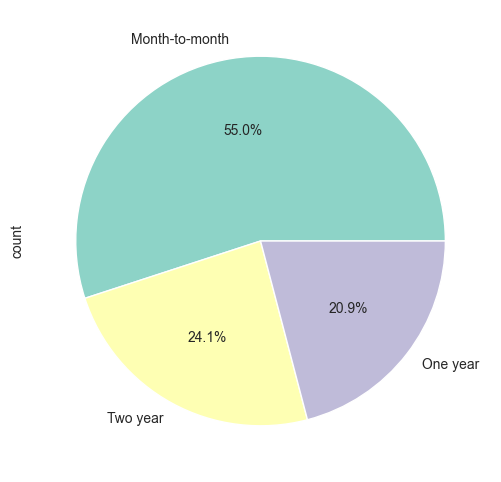

In [6]:
df['Contract'].value_counts().plot.pie(figsize=(10, 6), autopct='%1.1f%%')
#hier nutze ich die pandas Bibliothek, um mit .value_counts() zu bestimmen wie groß der Anteil der unterschiedlichen Verträge sind.
# Durch autopct='%1.1f%%' erzwinge ich den Anteil als %-Angabe mit genau einer Kommazahl darzustellen

## 4. Kündigungen in Abhängigkeit, ob Techsupport genutzt wurde

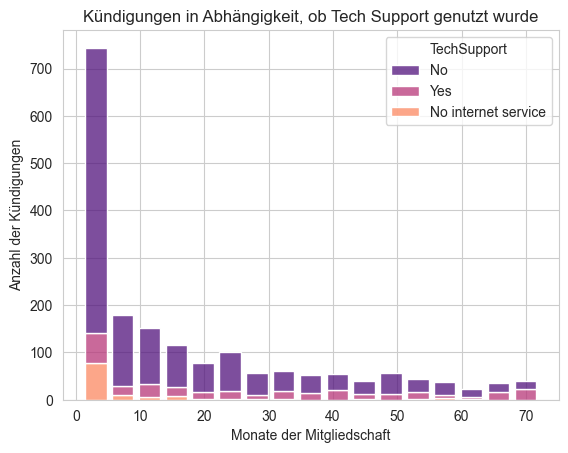

In [15]:
#weißes Gitter zum besseren Überblick hinzugefügt
sns.set_style("whitegrid")

#Gruppierung der Monthly Charges zum jeweiligen Contract
sns.histplot(data = churn_rate, x = 'tenure', hue = 'TechSupport', shrink=.8, multiple= "stack", palette = 'magma')
#Als Datenmenge nutze ich alle Kunden, die gekündigt haben. Die X-Achse beschreibt den Zeitpunkt.
# Mit hue und stack teile ich diese so auf, dass visuell eifach zu erkennen ist, ob der Kunde Technischen Support
# erhalten hat oder nicht. shrink fügt Abstände zwischen den Balken ein.

#Beschriftung
plt.title('Kündigungen in Abhängigkeit, ob Tech Support genutzt wurde')
plt.xlabel('Monate der Mitgliedschaft')
plt.ylabel('Anzahl der Kündigungen')

plt.savefig("TechSupport.png")

plt.show()

## 5. Alle Kündigungen und welcher Internet Service genutzt wurde

<Axes: xlabel='tenure', ylabel='Count'>

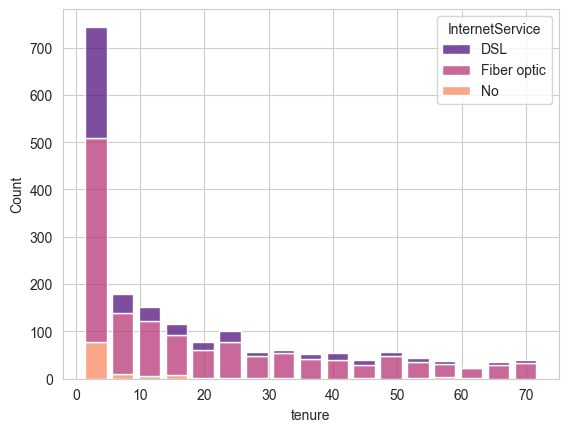

In [13]:
sns.histplot(data = churn_rate, x = 'tenure', hue = 'InternetService', shrink=.8, multiple= "stack", palette = 'magma')


## 6. Dieses Diagramm zeigt, wie sich die Bezahlmethode auf die Kündigungen auswirkt

<Axes: xlabel='PaymentMethod', ylabel='count'>

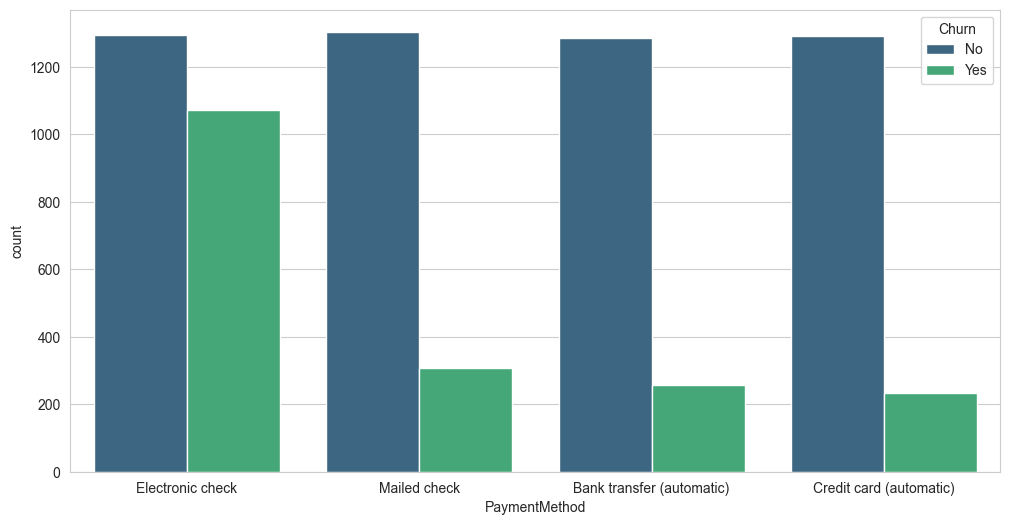

In [14]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='viridis')